In [218]:
# importing libraries
import pandas as pd # reading csv and excel files and data handling
import numpy as np # performs mathematical operations
import matplotlib.pyplot as plt # for graphical visualization
import seaborn as sns # for statistical visualization
from sklearn.model_selection import train_test_split, GridSearchCV # for splitting dataset into train and test
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler # for feature encoding and scaling
from sklearn.tree import DecisionTreeClassifier # for building model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score # for model evaluation

In [219]:
# loading dataset
df = pd.read_excel(r"C:\Users\rasika\Downloads\heart_disease.xlsx")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [220]:
# summary of dataset
df.info() # number of entries, number of columns, data type of column in dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [221]:
# Summary Statistics 
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [222]:
# checing for missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [223]:
# replacing missing values with mean
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['oldpeak']

0      2.3
1      0.0
2      0.4
3      0.0
4      1.5
      ... 
903    1.5
904    3.0
905    2.5
906    0.5
907    0.5
Name: oldpeak, Length: 908, dtype: float64

In [224]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [225]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [226]:
df['exang'].head() # this feature contains different cases (True, TRUE, FALSE), typo (TURE instead of TRUE) which shows inconsistency.

0    False
1    False
2    False
3    False
4     True
Name: exang, dtype: object

#### handling inconsistent column

In [227]:
# checking all unique values
df['exang'].unique() 

array([False, True, 'FALSE', 'TURE'], dtype=object)

In [228]:
#standardizing values
df['exang'] = df['exang'].astype(str).str.upper().str.strip() 
df['exang']

0      FALSE
1      FALSE
2      FALSE
3      FALSE
4       TRUE
       ...  
903    FALSE
904     TRUE
905     TRUE
906     TURE
907    FALSE
Name: exang, Length: 908, dtype: object

In [229]:
# fixing typo
df['exang'] = df['exang'].replace('TURE', 'TRUE')
df['exang']

0      FALSE
1      FALSE
2      FALSE
3      FALSE
4       TRUE
       ...  
903    FALSE
904     TRUE
905     TRUE
906     TRUE
907    FALSE
Name: exang, Length: 908, dtype: object

In [230]:
# converting to actual boolean
df['exang'] = df['exang'].replace({'FALSE' : False, 'TRUE' : True})
df['exang'].dtype

C:\Users\rasika\AppData\Local\Temp\ipykernel_25284\2448936822.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].replace({'FALSE' : False, 'TRUE' : True})


dtype('bool')

### Histogram for visualizing frequency distribution of numerical features and skewness

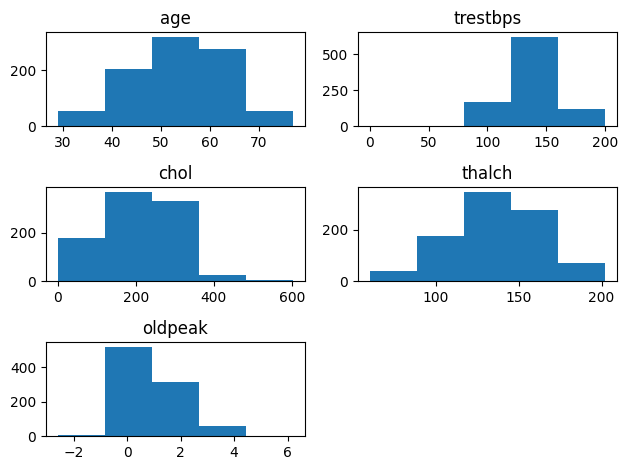

In [231]:
df.drop('num', axis = True).hist(grid = False, bins = 5)
plt.tight_layout()

#### Feature Distribution and Skewness
1. Age
Distribution is approximately bell-shaped.
Skewness: Slightly positively skewed.
2. Trestbps (Resting Blood Pressure)
Most values are concentrated between 120 and 150 mmHg.
Skewness: Moderately positively skewed.
3. Chol (Cholesterol)
Values are concentrated around 150–300 mg/dL.
Skewness: Strongly positively skewed.
4. Thalch (Maximum Heart Rate)
Distribution appears fairly symmetric and resembles a normal distribution.
Most observations lie between 120 and 170 bpm
Skewness: Approximately symmetric with slight negative skewness.
5. Oldpeak
Most values are clustered between 0 and 2.
Skewness: Strongly positively skewed.

### Boxplot for outlier detection

<Axes: >

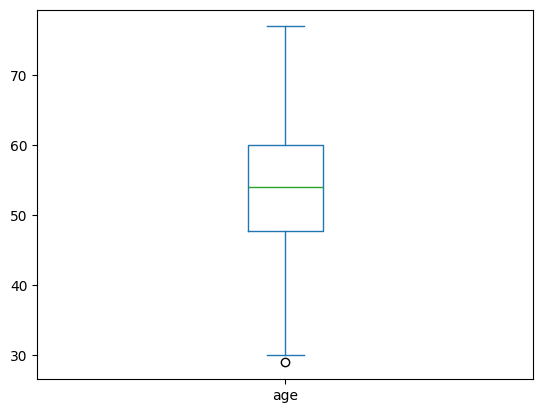

In [232]:
df['age'].plot(kind = 'box') # outlier present near wisker and it is not necessary to be removed for the age

<Axes: >

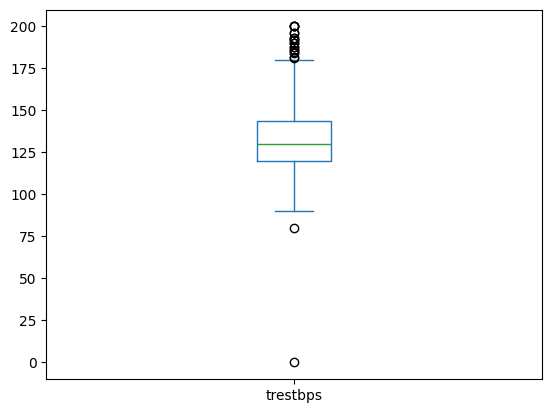

In [233]:
df['trestbps'].plot(kind = 'box')

<Axes: >

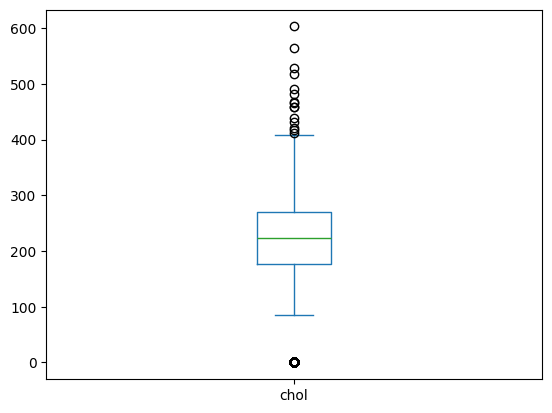

In [234]:
df['chol'].plot(kind = 'box')

<Axes: >

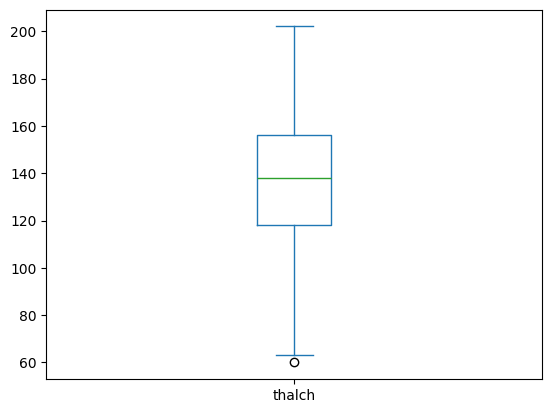

In [235]:
df['thalch'].plot(kind = 'box')

<Axes: >

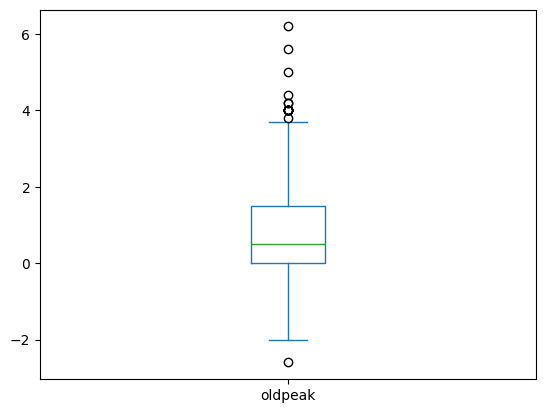

In [236]:
df['oldpeak'].plot(kind = 'box')

#### Outlier Removal

<Axes: >

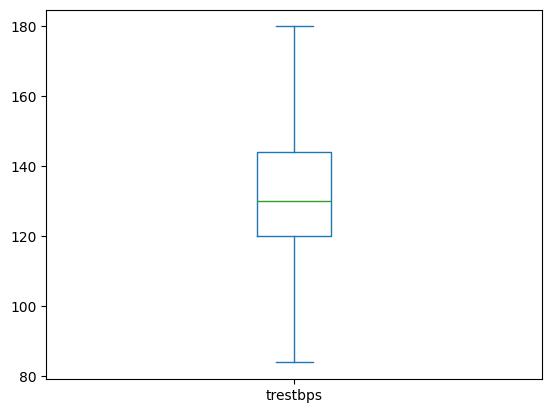

In [237]:
Q1 = df['trestbps'].quantile(0.25)
Q3 = df['trestbps'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['trestbps'] = df['trestbps'].clip(lower, upper)

df['trestbps'].plot(kind = 'box')

<Axes: >

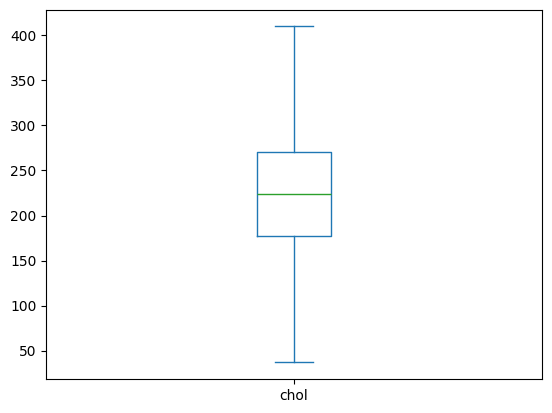

In [238]:
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['chol'] = df['chol'].clip(lower, upper)

df['chol'].plot(kind = 'box')

<Axes: >

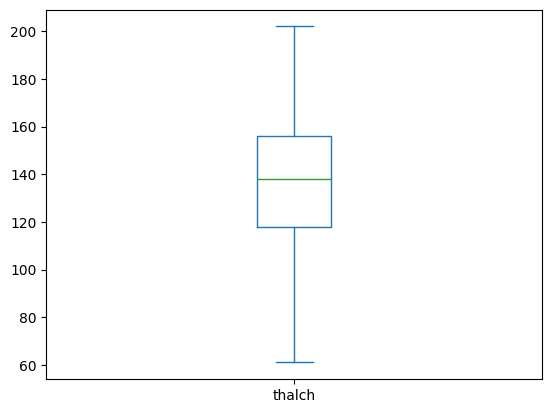

In [239]:
Q1 = df['thalch'].quantile(0.25)
Q3 = df['thalch'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['thalch'] = df['thalch'].clip(lower, upper)

df['thalch'].plot(kind = 'box')

<Axes: >

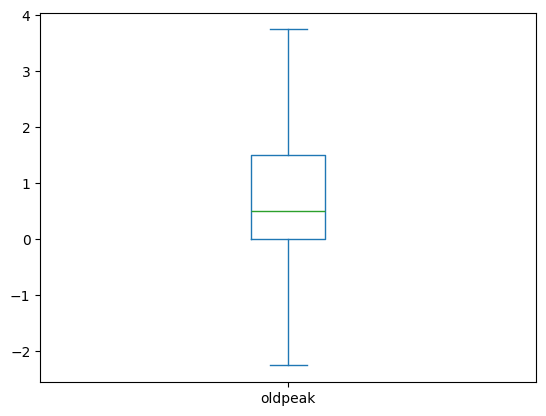

In [240]:
Q1 = df['oldpeak'].quantile(0.25)
Q3 = df['oldpeak'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['oldpeak'] = df['oldpeak'].clip(lower, upper)

df['oldpeak'].plot(kind = 'box')

#### Separating numerical and categorical columns to easily perform scaling and encoding

In [241]:
num_col = df.select_dtypes(include = ['int', 'float']).columns
cat_col = df.select_dtypes(include = 'object').columns
bool_col =  df.select_dtypes(include = 'bool').columns
print(num_col)
print(cat_col)
print(bool_col)

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')
Index(['sex', 'cp', 'restecg', 'slope', 'thal'], dtype='object')
Index(['fbs', 'exang'], dtype='object')


In [242]:
# creating numeric dataframe
df_num = df[num_col]
df_num.head()

,age,trestbps,chol,thalch,oldpeak,num
0,63,145,233.0,150,2.3,0
1,41,135,203.0,132,0.0,0
2,57,140,192.0,148,0.4,0
3,52,118,186.0,190,0.0,0
4,57,110,201.0,126,1.5,0


In [243]:
# creating categorical dataframe
df_cat = df[cat_col]
df_cat.head()

,sex,cp,restecg,slope,thal
0,Male,typical angina,lv hypertrophy,downsloping,fixed defect
1,Male,atypical angina,normal,flat,fixed defect
2,Male,asymptomatic,normal,flat,fixed defect
3,Male,typical angina,lv hypertrophy,flat,fixed defect
4,Male,asymptomatic,normal,flat,fixed defect


In [244]:
# creating boolean type dataframe
df_bool = df[bool_col]
df_bool.head()

,fbs,exang
0,True,False
1,False,False
2,False,False
3,False,False
4,False,True


#### Encoding 

In [245]:
# checking categories in each column
for col in cat_col:
    print(col, df[col].nunique())

sex 2
cp 4
restecg 3
slope 3
thal 3


In [246]:
le = LabelEncoder()
label_col = ['sex', 'cp', 'restecg', 'slope', 'thal', 'fbs', 'exang']
for col in label_col:
    df[col] = le.fit_transform(df[col])
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233.000,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203.000,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192.000,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186.000,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201.000,0,1,126,1,1.5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1,0,125,36.875,0,1,120,0,1.5,2,2,4
904,62,1,0,166,170.000,0,2,120,1,3.0,1,1,4
905,56,1,2,170,36.875,0,0,123,1,2.5,0,2,4
906,56,1,2,144,208.000,1,2,105,1,0.5,0,1,4


### Heatmap for Feature Correlation

<Axes: >

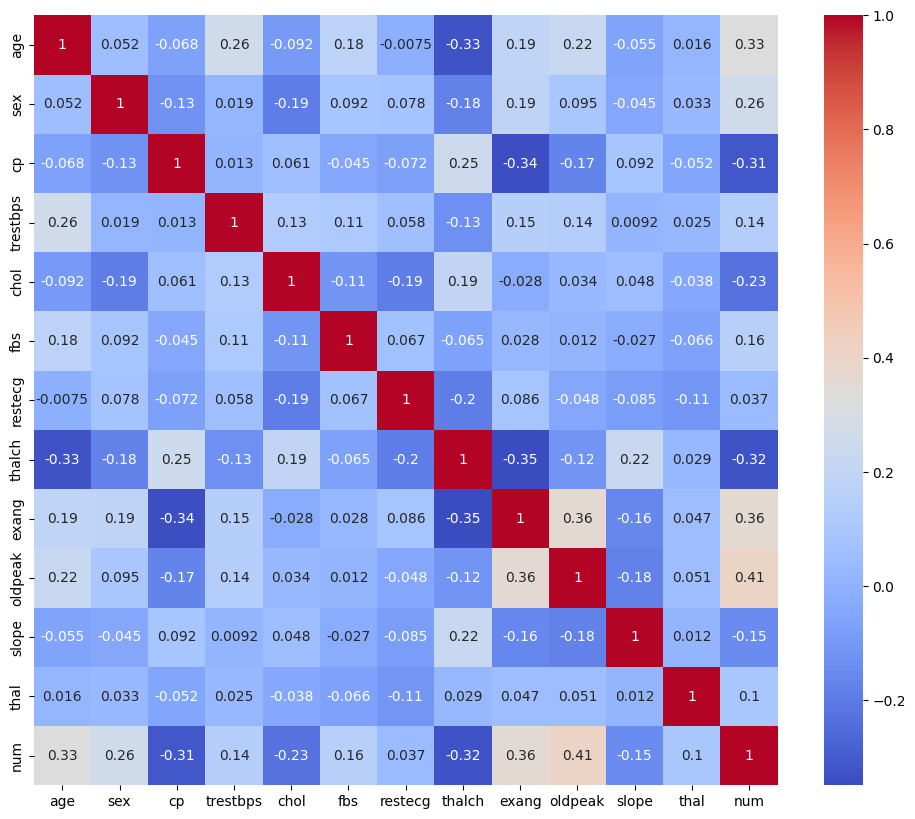

In [247]:
plt.figure(figsize = (12, 10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

#### No feature is strongly correlated with other feature

In [248]:
# Assigning features to variables
X = df.drop('num', axis = 1)
y = df['num']

In [250]:
# splitting 80% of dataset for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

dc = DecisionTreeClassifier(criterion = 'gini', max_depth = 5)

#training model
model_dc = dc.fit(X_train, y_train)
y_pred_train = dc.predict(X_train)
y_pred_test = dc.predict(X_test)

#### Model Evaluation

In [251]:
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average = 'weighted') # using weighted cause we have multiple classes in target colun
recall = recall_score(y_test, y_pred_test, average = 'weighted')
f1 = f1_score(y_test, y_pred_test, average = 'weighted')
accuracy1 = accuracy_score(y_train, y_pred_train)
print('Test Accuracy :', accuracy)
print('Precision :', precision)
print('Recall :', recall)
print('F1 Score :', f1)
print('Train Accuracy :', accuracy1)

Test Accuracy : 0.554945054945055
Precision : 0.5126789177209345
Recall : 0.554945054945055
F1 Score : 0.5222143835545897
Train Accuracy : 0.6225895316804407


In [252]:
y_prob = dc.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7786780927405926


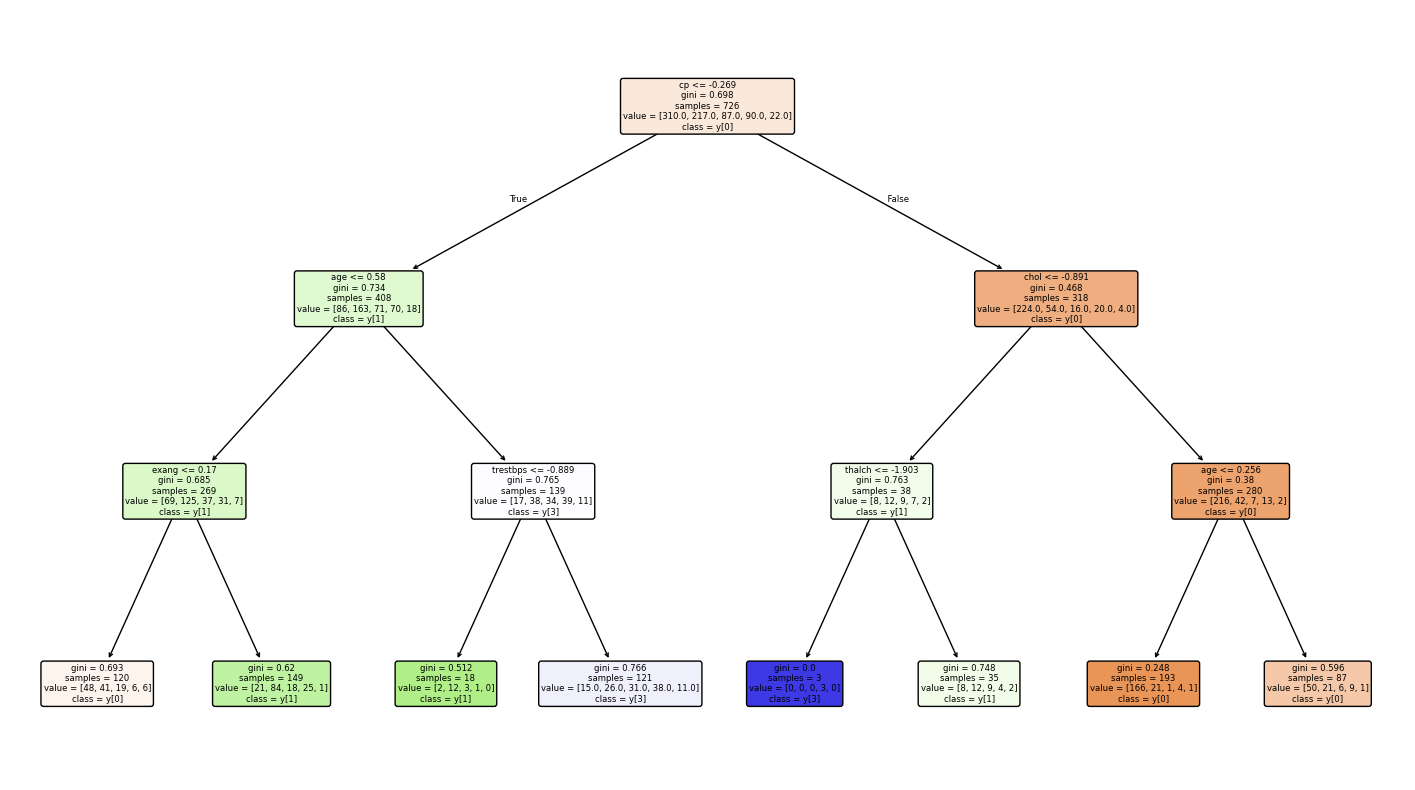

In [257]:
# DecisionTree Visualization
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    rounded=True
)
plt.show()

### Hyperparameter Tuning

In [254]:
# Tests combinations for all the parameters and with GridSearchCV gives best combination of parameters and best_model with model accuracy
param_grid = {'criterion' : ['gini', 'entropy'],
             'max_depth' : [3, 5, 7],
             'min_samples_split' : [2, 5, 10]}
grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv = 5,
    scoring = 'accuracy')

grid.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [255]:
print(grid.best_params_) # best parameters
print(grid.best_score_) # best accuracy

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
0.530307038261691


In [ ]:
### Dataset have multiple classes in target column so model underfits but still with multipple classes 53% accuracy is better 

In [256]:
# Important feature analysis
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
2         cp    0.561583
0        age    0.149249
4       chol    0.132195
8      exang    0.085982
3   trestbps    0.043602
7     thalch    0.027389
1        sex    0.000000
5        fbs    0.000000
6    restecg    0.000000
9    oldpeak    0.000000
10     slope    0.000000
11      thal    0.000000


##### 
1. Most important feature: cp (56.16%)
2. Second most important feature: age (14.92%)
3. Third most important feature: chol (13.22%)
4. Least important features: sex, fbs, restecg, oldpeak, slope, thal (0%)
5. The model relied heavily on cp, suggesting that chest pain type is the strongest predictor of heart disease in this dataset

### Interview Questions
What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
   
1. Criterion:
The criterion determines how the algorithm chooses the best split at each node.
a. Gini measures impurity and is generally faster.
b. Entropy uses information gain and can sometimes produce a more informative tree.

2. Max Depth (max_depth):
This specifies the maximum depth of the tree.
A larger depth allows the tree to learn more complex patterns but may lead to overfitting.
A smaller depth prevents overfitting but may cause underfitting if the tree is too simple.

3. Minimum Samples Split (min_samples_split):
This defines the minimum number of samples required to split a node.
A small value allows more splits, making the tree more complex.
A larger value reduces unnecessary splits and improves generalization

What is the difference between the Label encoding and One-hot encoding?

In Label Encoding, each category is assigned a unique numerical value.

In One-Hot Encoding, categorical value converted into binary vectors.